In [1]:
import os
from glob import glob
import numpy as np
import uproot
import matplotlib as mpl
import matplotlib.pyplot as plt
import awkward as ak  # Needed if using awkward arrays
from matplotlib.ticker import MultipleLocator, FuncFormatter
plt.style.use('fcc.mplstyle')


import config as cfg
import efficiency_finder

In [2]:
# data with no cuts and MC info for the quarks
base_folder = '/r01/lhcb/ejnw2/fcc/FCC_outputs_2025/outputs_28Jan25/no_selection_no_nlept_var/'

In [3]:
def histogram_settings():
    
    hist_settings = { allocation: {} for allocation in cfg.sample_allocations }
    total_color = { allocation: {} for allocation in cfg.sample_allocations }

    for allocation in cfg.sample_allocations:
        samples = cfg.sample_allocations[allocation]
            
        if allocation=='Bssignal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[3]) #'cornflowerblue'
            hist_settings[allocation]['hatch'] = '////'
        elif allocation=='Bdsignal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[-2]) #'mediumblue'#'royalblue'
            hist_settings[allocation]['hatch'] = r'\\\\'
        elif allocation=='combined_signal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] =plt.cm.Blues( np.linspace(0, 1, len(samples)+4)[3:-1] ) #['cornflowerblue','mediumblue']#['cornflowerblue', 'dodgerblue',]#['cadetblue','teal']#['cornflowerblue','mediumblue']
            total_color[allocation] = 'midnightblue'
            hist_settings[allocation]['hatch'] = '////'

        elif allocation=='hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(samples)+2)[1:-1] )
            total_color[allocation] = 'k'
        elif allocation=='light_hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[3:-1] )
            total_color[allocation] = 'indianred'
        elif allocation=='heavy_hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1:3] )
            total_color[allocation] = 'darkred'
        elif allocation=='bb_only':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['lw'] = 2
            #hist_settings[allocation]['alpha'] = 0.6
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )

        elif allocation=='tau_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b((4+ np.linspace(0, 1, len(cfg.sample_allocations['leptonic_background'])+2)[1])/5 )#'mediumvioletred'
            total_color[allocation] = 'indigo'
        elif allocation=='leptonic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b( (4+np.linspace(0, 1, len(samples)+2)[1:-1]) /5 )# plt.cm.tab20b((4+ np.linspace(0, 1, len(samples)))/5 ) #plt.cm.PuRd_r( np.linspace(0, 1, len(samples)+2)[1:-1] ) 
            total_color[allocation] = 'indigo'#'purple'
        elif allocation=='light_leptonic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b((4+ np.linspace(0, 1, len(cfg.sample_allocations['leptonic_background'])+2)[2:-1])/5 )
            total_color[allocation] = 'mediumvioletred'

    return hist_settings, total_color

In [4]:
def as_array(folder, varname, cut, nchunks,inputpath):
    if nchunks is not None:
        files = glob(os.path.join(os.path.abspath(inputpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inputpath), folder, "*.root:events" )

    try: 
        # awkward array instead of numpy -> allows variable length elements
        #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
        arr = uproot.concatenate( path, expressions=varname, cut=cut)[varname]
    except:
        branches = get_list_of_branches(folder,inputpath)
        print( f"Branches found in files at path {folder}:" )
        for br in branches:
            print('  ', br)
        raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )

    # Return awkward array as a flattened ndarray
    return ak.to_numpy(ak.ravel(arr))


In [5]:
def get_list_of_files(folder,inputpath):
    
    path = os.path.join( inputpath, folder )
    if not os.path.exists( path ):
        raise RuntimeError( f"No such path {path}" )
    
    files = glob( os.path.join(inputpath, folder, "*.root") )
    if len(files)==0:
        raise RuntimeError( f"No root files found in {path}" )

    return files
    
def get_list_of_branches(folder,inputpath):
    f0 = get_list_of_files(folder,inputpath)[0]
    try:
        tr = uproot.open( f0+":events" )
        return [ br.name for br in tr.branches ]
    except:
        raise RuntimeError( f"No tree called events found in file {f0}" )

# quark-thrust angle plot

In [6]:
bbpath = os.path.join(base_folder,'p8_ee_Zbb_ecm91/chunk_0.root')
sigpath = os.path.join(base_folder,'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu/chunk_0.root')

In [7]:
variables=[  'MCq2_p', 'MCq2_px', 'MCq2_py', 'MCq2_pz','MCq1_p', 'MCq1_px', 'MCq1_py', 'MCq1_pz', 'EVT_unitThrust_x', 'EVT_unitThrust_y', 'EVT_unitThrust_z' ]

sig_arr = uproot.concatenate( sigpath, expressions=variables)
bb_arr = uproot.concatenate( bbpath, expressions=variables)

In [8]:
sig_arr['MCq2_p']

MCq1_p_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_p'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_p']}
MCq1_px_values =  {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_px'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_px']}
MCq1_py_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_py'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_py']}
MCq1_pz_values =  {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_pz'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_pz']}
MCq2_p_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_p'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_p']}
MCq2_px_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_px'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_px']}
MCq2_py_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_py'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_py']}
MCq2_pz_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_pz'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_pz']}
EVT_Thrust_x_values =  {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['EVT_unitThrust_x'], 'p8_ee_Zbb_ecm91':bb_arr['EVT_unitThrust_x']}
EVT_Thrust_y_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['EVT_unitThrust_y'], 'p8_ee_Zbb_ecm91':bb_arr['EVT_unitThrust_y']}
EVT_Thrust_z_values  = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['EVT_unitThrust_z'], 'p8_ee_Zbb_ecm91':bb_arr['EVT_unitThrust_z']}

costheta1 = {sample: (MCq1_px_values[sample]*EVT_Thrust_x_values[sample]+MCq1_py_values[sample]*EVT_Thrust_y_values[sample]+MCq1_pz_values[sample]*EVT_Thrust_z_values[sample])/(MCq1_p_values[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}
theta1 = {sample: np.arccos(costheta1[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}

costheta2 = {sample: (MCq2_px_values[sample]*EVT_Thrust_x_values[sample]+MCq2_py_values[sample]*EVT_Thrust_y_values[sample]+MCq2_pz_values[sample]*EVT_Thrust_z_values[sample])/(MCq2_p_values[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}
theta2 = {sample: np.arccos(costheta2[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}

/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-almalinux9-gcc11.3.1-opt/py-awkward/2.1.1-xagkwd/lib/python3.10/site-packages/awkward/_backends.py:58: RuntimeWarning: invalid value encountered in arccos
  return getattr(ufunc, method)(*args, **kwargs)


(array([46345.,  1843.,   702.,   414.,   182.,   155.,   374.,   735.,
         1839., 46477.]),
 array([0.        , 0.31415927, 0.62831855, 0.94247782, 1.2566371 ,
        1.57079637, 1.88495564, 2.1991148 , 2.51327419, 2.82743359,
        3.14159274]),
 <BarContainer object of 10 artists>)

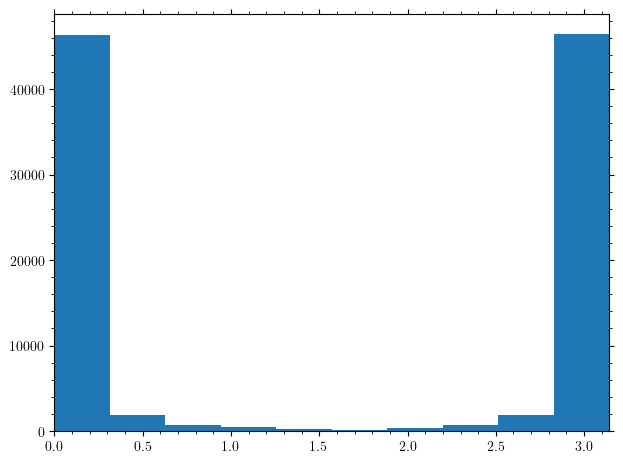

In [10]:
plt.hist(theta1['p8_ee_Zbb_ecm91'])

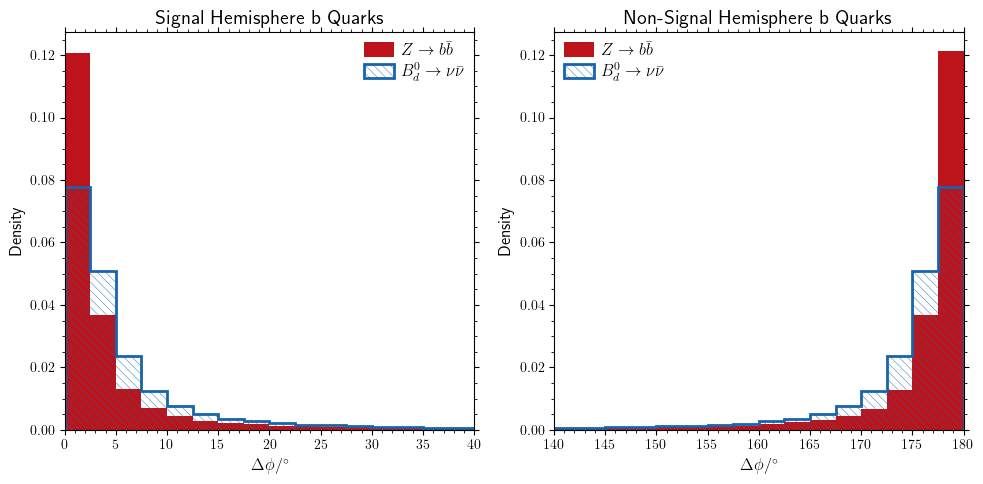

In [25]:
samples =  ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']



fig, axs = plt.subplots(1, 2, figsize=(10, 5))
nbins=72

hist_settings,total_colours = histogram_settings()

for sample in samples:
    values1 = theta1[sample]/(2*np.pi)*360
    values2 = theta2[sample]/(2*np.pi)*360
    hist_x = values1
    hist_l = cfg.titles[sample]
    if sample == 'p8_ee_Zbb_ecm91':
        hist_opts = hist_settings['bb_only']
        tot_colour= total_colours['bb_only']
    else:
        hist_opts = hist_settings['Bdsignal']
        tot_colour= total_colours['Bdsignal']

    hist_w = None

    hist_opts['stacked'] = False

    axs[0].hist( 
        x = hist_x,
        bins = nbins,
        density = True,
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )

    axs[1].hist( 
        x = hist_x,
        bins = nbins,
        density = True,
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )


axs[0].legend(reverse=True)
axs[0].set_xlabel(r'$\Delta \phi /  ^{\circ}$')
axs[0].set_xlim(0,40)
#ax.set_yscale('log')
axs[0].set_ylabel('Density')

axs[1].legend(reverse=True)
axs[1].set_xlabel(r'$\Delta \phi /  ^{\circ}$')
axs[1].set_xlim(140,180)
#ax.set_yscale('log')
axs[1].set_ylabel('Density')

''' only needed if working in radians
base_no = 8
def format_func(value, tick_number):
    # Convert the value to a fraction of π
    frac = value / np.pi
    if np.isclose(frac, 0):  # Handle 0
        return "0"
    elif np.isclose(frac, 1):  # Handle π
        return r"$\pi$"
    elif np.isclose(frac, -1):  # Handle -π
        return r"-$\pi$"
    else:
        numerator, denominator = int(np.round(frac * base_no)), base_no  # Adjust denominator as needed
        while numerator % 2 == 0 and denominator % 2 == 0:  # Simplify fraction
            numerator //= 2
            denominator //= 2
        if denominator == 1:  # If it's an integer multiple of π
            return f"{numerator}"+r"$\pi$"
        if numerator ==1:
            return r"$\pi$"+f"/{denominator}"
        else:
            return f"{numerator}"+r"$\pi$"+f"/{denominator}"




axs[0].xaxis.set_major_locator(MultipleLocator(base=np.pi / base_no))  # Set tick spacing
axs[0].xaxis.set_major_formatter(FuncFormatter(format_func))     # Format ticks as fractions of π


axs[1].xaxis.set_major_locator(MultipleLocator(base=np.pi / base_no))  # Set tick spacing
axs[1].xaxis.set_major_formatter(FuncFormatter(format_func))     # Format ticks as fractions of π

'''

#fig.suptitle('Angle Between Thrust Axis and True MC b Quark Momentum ')

axs[0].set_title('Signal Hemisphere b Quarks')
axs[1].set_title('Non-Signal Hemisphere b Quarks')

plt.savefig('b_thrust_angle_degrees.pdf')
plt.show()




# prelim cut plots

In [25]:
inputpath = '/r01/lhcb/ejnw2/fcc/FCC_outputs_2025/outputs_28Jan25/no_selection/'
vars = ['EVT_e','EVT_hemisEmin_nCharged','EVT_hemisEmin_nLept','EVT_hemisEmax_n']
ax1= [0,0,1,1]
ax2 = [0,1,0,1]
cuts = [85, 1,1,10]
bkg_components = ['hadronic_background','hadronic_background','hadronic_background','hadronic_background']# 'tau_background' for final sample one generated needed data
xtitle = ['Total Event Energy /GeV', 'Number of Charged Particles in Signal Hemiphere', r'Number of e and $\mu$ in Signal Hemiphere', 'Particle Multiplicity in Non-Signal Hemisphere']
nchunks=None
cut = None
total=["hadronic_background"]
save = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/paper_plots' 
signal_bf = 1e-7 # not relevant as density =True in plot

In [26]:
values = [0] * len(vars)
effs =  [0] * len(vars)
n_expect = [0] * len(vars)
xmin =  [0] * len(vars)
xmax = [0] * len(vars)
nbins = [0] * len(vars)
for p in range(len(vars)):
    varname = vars[p]
    components = ["combined_signal",bkg_components[p]]
    decays_list = [cfg.sample_allocations[i] for i in components]
    flat_decays_list = [item for sublist in decays_list for item in sublist]

    values[p] = { sample: as_array(sample, varname, cut, nchunks,inputpath) for sample in flat_decays_list }
    effs[p] = efficiency_finder.get_efficiencies('custom', cut=cut, raw=True, custompath=inputpath, verbose=False,samples=flat_decays_list)
    n_expect[p] = efficiency_finder.get_sample_expectations(effs[p], signal_bf, save=None, verbose=False, cut=cut)

    xmin[p] = min( [ min(values[p][sample]) for sample in values[p] ] )
    xmax[p] = max( [ max(values[p][sample]) for sample in values[p] ] )

    # If variable is an integer make sure nbins correct
    #for most variables nbins=xmax-xmin
    #unless ChargedRP_fromPV_transformed

    if 'ChargedRP_fromPV_transformed' in varname:
        nbins=3
    elif '_n' in varname and '_norm' not in varname:
        print(varname)
        xmin[p] = 0
        nbins[p]= int(xmax[p] - xmin[p])
    else:
        nbins[p]=50

EVT_hemisEmin_nCharged
EVT_hemisEmin_nLept
EVT_hemisEmax_n


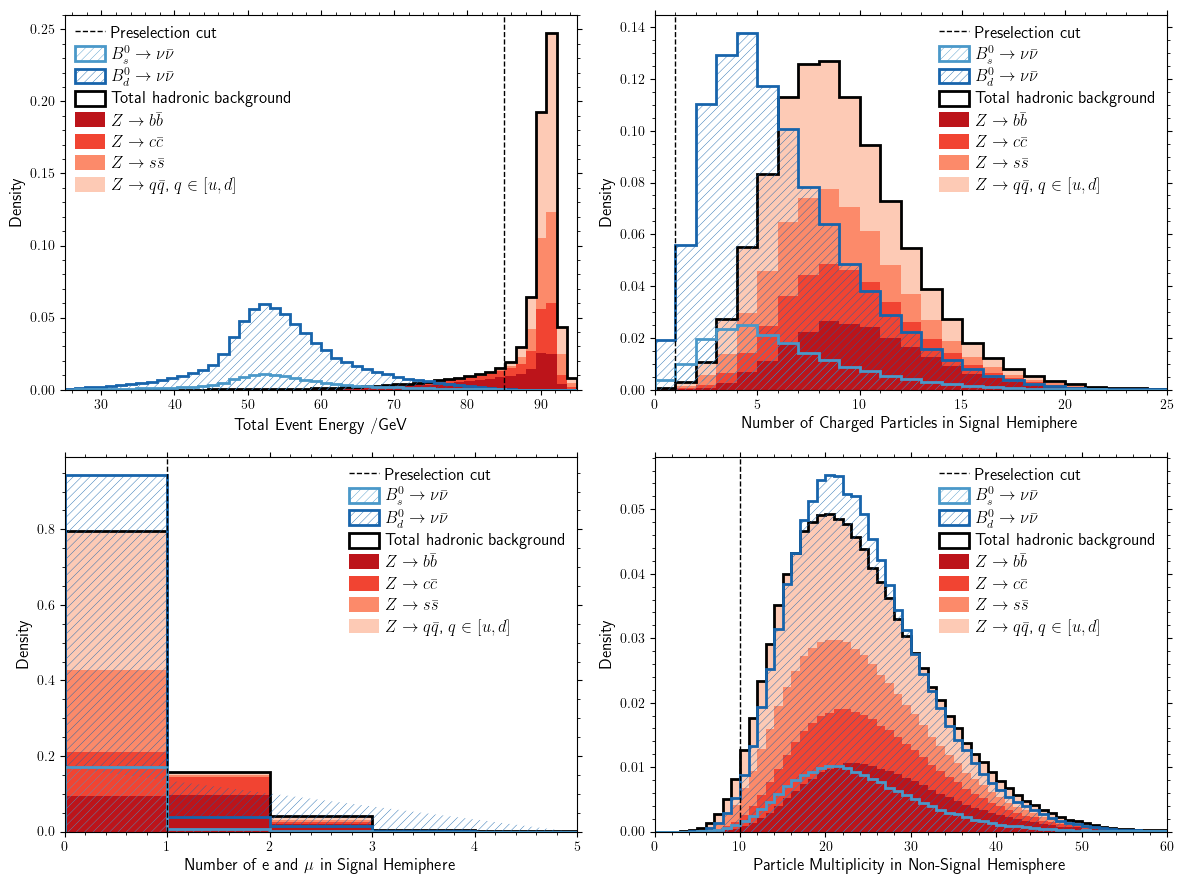

In [30]:
xmin[0] = 25 
xmax[0] = 95 
xmax[1] = 25
nbins[1] = 25
xmax[2] = 5
nbins[2] = 5
xmax[3] = 60
nbins[3] = 60
fig, axs = plt.subplots(2,2, figsize=(12, 9))

hist_settings,total_colours = histogram_settings()

for p in range(len(vars)):
    for allocation in cfg.sample_allocations:
        if allocation not in components:
            continue
        samples = cfg.sample_allocations[allocation]
        hist_x = [ values[p][sample] for sample in samples ]
        hist_l = [ cfg.titles[sample] for sample in samples ]
        hist_opts = hist_settings[allocation]
        tot_colour= total_colours[allocation]

        hist_w = [ np.ones_like(values[p][sample])*n_expect[p][sample+'_num']/len(values[p][sample]) for sample in samples ]

        hist_opts['stacked'] = True

    
        axs[ax1[p]][ax2[p]].hist( 
            x = hist_x,
            bins = nbins[p],
            range = (xmin[p],xmax[p]),
            density = True,
            label = hist_l,
            weights = hist_w,
            **hist_opts
            )

        if allocation in total:
            axs[ax1[p]][ax2[p]].hist( 
                np.concatenate(hist_x), 
                bins = nbins[p],
                range = (xmin[p],xmax[p]),
                density = True,
                label = f'Total {allocation.replace("_", " ")}',
                weights = np.concatenate( hist_w ),
                histtype = 'step',
                color = tot_colour,#'k',
                lw = 2,
            )
    axs[ax1[p]][ax2[p]].axvline(x=cuts[p], c='k',linestyle='--',label='Preselection cut')
    axs[ax1[p]][ax2[p]].legend(reverse=True)
    axs[ax1[p]][ax2[p]].set_xlabel(xtitle[p])
    axs[ax1[p]][ax2[p]].set_ylabel('Density')
    #ax.set_ylim(yrange)

fig.tight_layout()
plt.show()
#fig.savefig(save)

# Need for multiclass approach

In [12]:
inputpath = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data'
vars = ['EVT_hemisEmin_nDV','EVT_hemisEmin_nDV','EVT_hemisEmax_nDV','EVT_hemisEmax_nDV']
ax1= [0,0,1,1]
ax2 = [0,1,0,1]
bkg_components = ['heavy_hadronic_background','light_hadronic_background','heavy_hadronic_background','light_hadronic_background']
xtitle = ['Number of Displaced Vertices, Signal Hemisphere', 'Number of Displaced Vertices, Signal Hemiphere', r'Number of Displaced Vertices, Non-Signal Hemisphere', 'Number of Displaced Vertices, Non-Signal Hemisphere']
nchunks=1
cut = None
total=['heavy_hadronic_background','light_hadronic_background']
save = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/paper_plots' 
signal_bf = 1e-7 # not relevant as density =True in plot

In [13]:
values = [0] * len(vars)
effs =  [0] * len(vars)
n_expect = [0] * len(vars)
xmin =  [0] * len(vars)
xmax = [0] * len(vars)
nbins = [0] * len(vars)
components = [0] * len(vars)
for p in range(len(vars)):
    varname = vars[p]
    components[p] = ["combined_signal",bkg_components[p]]
    decays_list = [cfg.sample_allocations[i] for i in components[p]]
    flat_decays_list = [item for sublist in decays_list for item in sublist]

    values[p] = { sample: as_array(sample, varname, cut, nchunks,inputpath) for sample in flat_decays_list }
    effs[p] = efficiency_finder.get_efficiencies('custom', cut=cut, raw=True, custompath=inputpath, verbose=False,samples=flat_decays_list)
    n_expect[p] = efficiency_finder.get_sample_expectations(effs[p], signal_bf, save=None, verbose=False, cut=cut)

    xmin[p] = min( [ min(values[p][sample]) for sample in values[p] ] )
    xmax[p] = max( [ max(values[p][sample]) for sample in values[p] ] )

    # If variable is an integer make sure nbins correct
    #for most variables nbins=xmax-xmin
    #unless ChargedRP_fromPV_transformed

    if 'ChargedRP_fromPV_transformed' in varname:
        nbins[p]=3
    elif '_n' in varname and '_norm' not in varname:
        print(varname)
        xmin[p] = 0
        nbins[p]= int(xmax[p] - xmin[p])
    else:
        nbins[p]=50

EVT_hemisEmin_nDV
EVT_hemisEmin_nDV
EVT_hemisEmax_nDV
EVT_hemisEmax_nDV


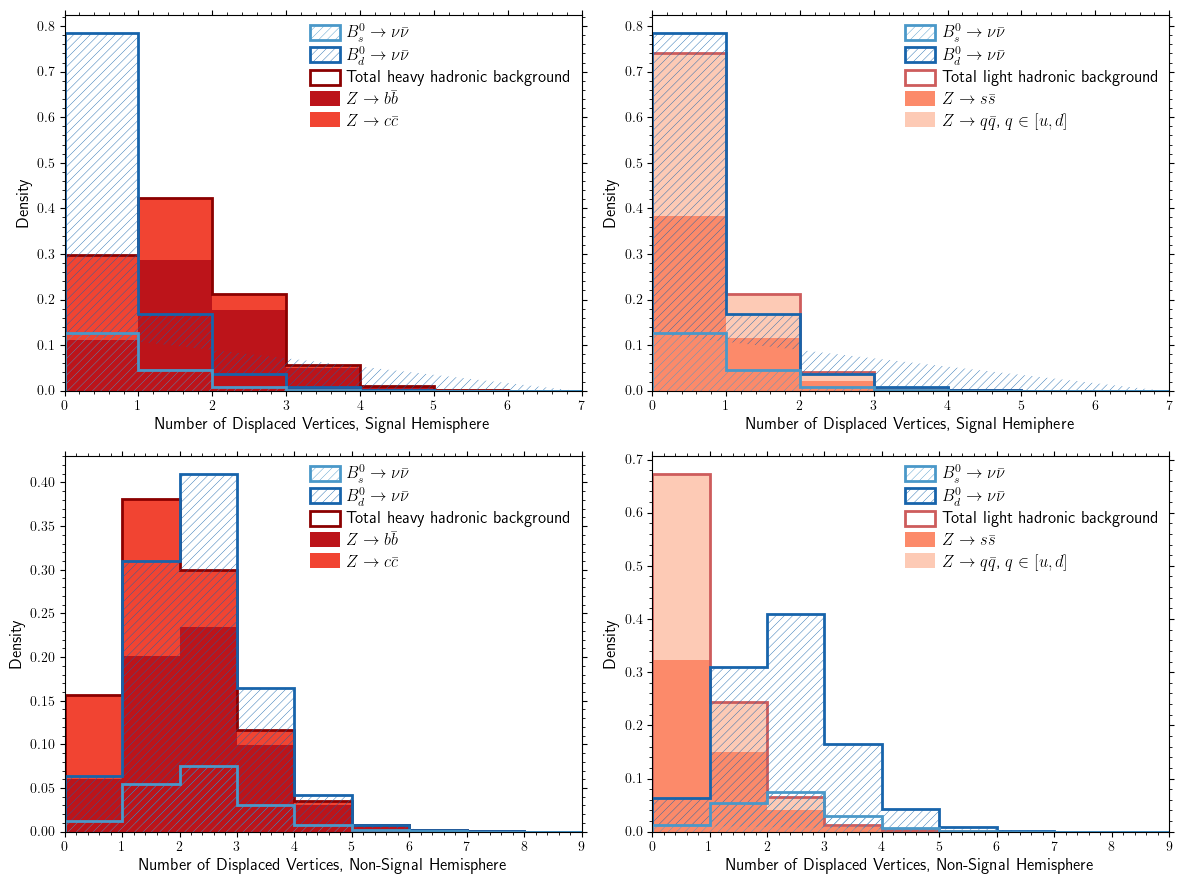

In [14]:
fig, axs = plt.subplots(2,2, figsize=(12, 9))

hist_settings,total_colours = histogram_settings()

for p in range(len(vars)):
    for allocation in cfg.sample_allocations:
        if allocation not in components[p]:
            continue
        samples = cfg.sample_allocations[allocation]
        hist_x = [ values[p][sample] for sample in samples ]
        hist_l = [ cfg.titles[sample] for sample in samples ]
        hist_opts = hist_settings[allocation]
        tot_colour= total_colours[allocation]

        hist_w = [ np.ones_like(values[p][sample])*n_expect[p][sample+'_num']/len(values[p][sample]) for sample in samples ]

        hist_opts['stacked'] = True

    
        axs[ax1[p]][ax2[p]].hist( 
            x = hist_x,
            bins = nbins[p],
            range = (xmin[p],xmax[p]),
            density = True,
            label = hist_l,
            weights = hist_w,
            **hist_opts
            )

        if allocation in total:
            axs[ax1[p]][ax2[p]].hist( 
                np.concatenate(hist_x), 
                bins = nbins[p],
                range = (xmin[p],xmax[p]),
                density = True,
                label = f'Total {allocation.replace("_", " ")}',
                weights = np.concatenate( hist_w ),
                histtype = 'step',
                color = tot_colour,#'k',
                lw = 2,
            )

    axs[ax1[p]][ax2[p]].legend(reverse=True)
    axs[ax1[p]][ax2[p]].set_xlabel(xtitle[p])
    axs[ax1[p]][ax2[p]].set_ylabel('Density')
    #ax.set_ylim(yrange)

fig.tight_layout()
plt.show()
#fig.savefig(save)

## PV flag - messy

In [6]:
inputpath = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data'
vars = ['EVT_hemisEmin_maxpChargedRP_fromPV_transformed','EVT_hemisEmin_maxpChargedRP_fromPV_transformed','EVT_hemisEmax_maxpChargedRP_fromPV_transformed','EVT_hemisEmax_maxpChargedRP_fromPV_transformed']
ax1= [0,0,1,1]
ax2 = [0,1,0,1]
bkg_components = ['heavy_hadronic_background','light_hadronic_background','heavy_hadronic_background','light_hadronic_background']
xtitle = ['PV Flag for Maxiumum Momentum Charges RP, Signal Hemisphere', 'PV Flag for Maxiumum Momentum Charges RP, Signal Hemiphere', r'PV Flag for Maxiumum Momentum Charges RP, Non-Signal Hemisphere', 'PV Flag for Maxiumum Momentum Charges RP, Non-Signal Hemisphere']
nchunks=1
cut = None
total=['heavy_hadronic_background','light_hadronic_background']
save = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/paper_plots' 
signal_bf = 1e-7 # not relevant as density =True in plot

In [10]:
values = [0] * len(vars)
effs =  [0] * len(vars)
n_expect = [0] * len(vars)
xmin =  [0] * len(vars)
xmax = [0] * len(vars)
nbins = [0] * len(vars)
components = [0] * len(vars)
for p in range(len(vars)):
    varname = vars[p]
    components[p] = ["combined_signal",bkg_components[p]]
    decays_list = [cfg.sample_allocations[i] for i in components[p]]
    flat_decays_list = [item for sublist in decays_list for item in sublist]

    values[p] = { sample: as_array(sample, varname, cut, nchunks,inputpath) for sample in flat_decays_list }
    effs[p] = efficiency_finder.get_efficiencies('custom', cut=cut, raw=True, custompath=inputpath, verbose=False,samples=flat_decays_list)
    n_expect[p] = efficiency_finder.get_sample_expectations(effs[p], signal_bf, save=None, verbose=False, cut=cut)

    xmin[p] = min( [ min(values[p][sample]) for sample in values[p] ] )
    xmax[p] = max( [ max(values[p][sample]) for sample in values[p] ] )

    # If variable is an integer make sure nbins correct
    #for most variables nbins=xmax-xmin
    #unless ChargedRP_fromPV_transformed

    if 'ChargedRP_fromPV_transformed' in varname:
        nbins[p]=3
    elif '_n' in varname and '_norm' not in varname:
        print(varname)
        xmin[p] = 0
        nbins[p]= int(xmax[p] - xmin[p])
    else:
        nbins[p]=50

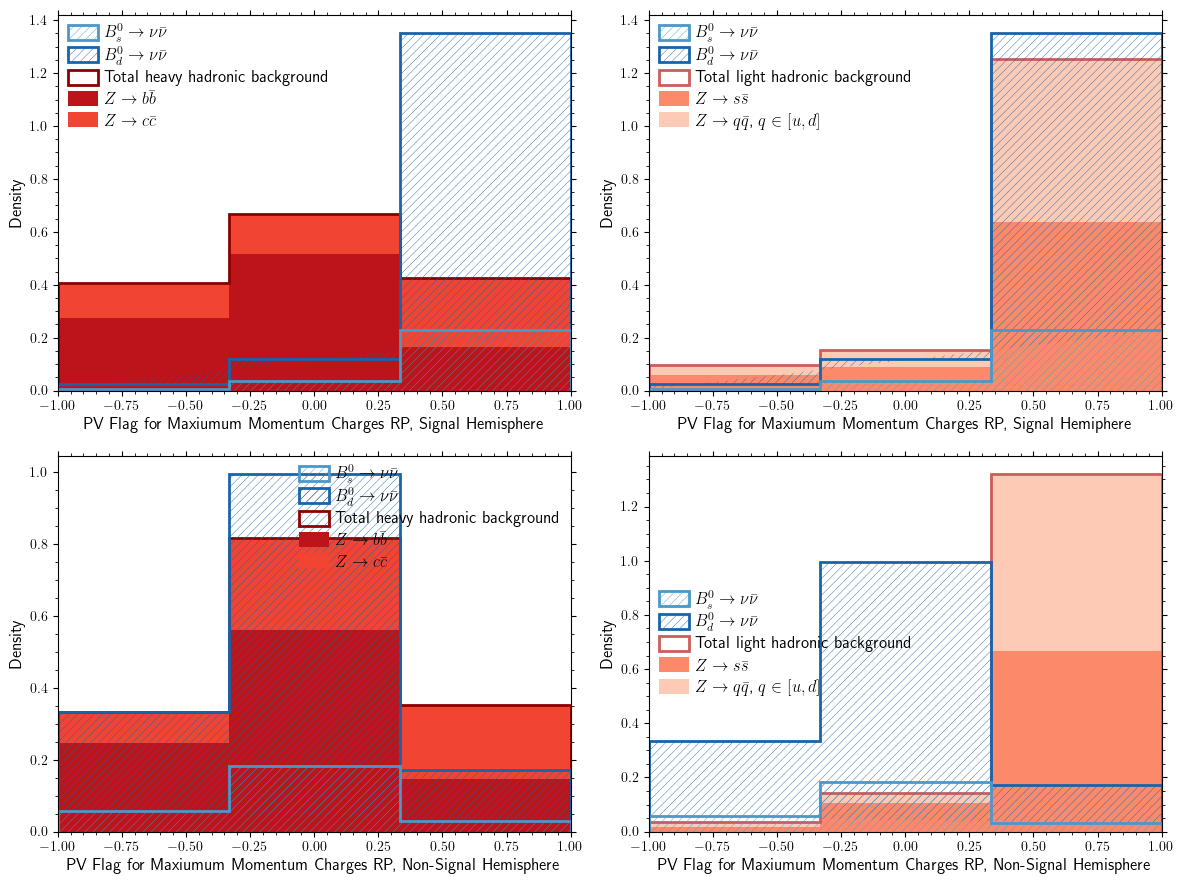

In [11]:
fig, axs = plt.subplots(2,2, figsize=(12, 9))

hist_settings,total_colours = histogram_settings()

for p in range(len(vars)):
    for allocation in cfg.sample_allocations:
        if allocation not in components[p]:
            continue
        samples = cfg.sample_allocations[allocation]
        hist_x = [ values[p][sample] for sample in samples ]
        hist_l = [ cfg.titles[sample] for sample in samples ]
        hist_opts = hist_settings[allocation]
        tot_colour= total_colours[allocation]

        hist_w = [ np.ones_like(values[p][sample])*n_expect[p][sample+'_num']/len(values[p][sample]) for sample in samples ]

        hist_opts['stacked'] = True

    
        axs[ax1[p]][ax2[p]].hist( 
            x = hist_x,
            bins = nbins[p],
            range = (xmin[p],xmax[p]),
            density = True,
            label = hist_l,
            weights = hist_w,
            **hist_opts
            )

        if allocation in total:
            axs[ax1[p]][ax2[p]].hist( 
                np.concatenate(hist_x), 
                bins = nbins[p],
                range = (xmin[p],xmax[p]),
                density = True,
                label = f'Total {allocation.replace("_", " ")}',
                weights = np.concatenate( hist_w ),
                histtype = 'step',
                color = tot_colour,#'k',
                lw = 2,
            )

    axs[ax1[p]][ax2[p]].legend(reverse=True)
    axs[ax1[p]][ax2[p]].set_xlabel(xtitle[p])
    axs[ax1[p]][ax2[p]].set_ylabel('Density')
    #ax.set_ylim(yrange)

fig.tight_layout()
plt.show()
#fig.savefig(save)